<a href="https://colab.research.google.com/github/nightsky18/Aprendizaje-de-maquinas/blob/main/Cuaderno_2_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##***Flujo del proyecto***
1. Análisis exploratorio de los datos (EDA)
2. Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas
3. Entrenamiento de los modelos: Cuantos? Cuáles? --> Depende de las métricas
4. Evaluación: Comparar métricas
5. Tunning de hiperparámetros
6. Modelo final --> Producción


##Análisis Exploratorio


###1. Importar los datos

In [48]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn import preprocessing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

In [ ]:
wine= load_wine()

df= pd.DataFrame(data= wine.data, columns= wine.feature_names)
df['target'] = wine.target
df['target_name']= df['target'].map({i: name for i, name in enumerate(wine.target_names)}) #compresión de expresiones

print("Dataset: Wine")
print(f'Muestras: {df.shape[0]}') #Dimensiones filas -# registros
print(f'Características: {df.shape[1]-2}') #Dimensiones columnas -# No necesito target ni indice
print(f'Clases: {list(wine.target_names)}')
print(f'Descripción: {wine.DESCR[:500]}')
#


Dataset: Wine
Muestras: 178
Características: 13
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Descripción: .. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0


###2. Análisis

In [ ]:
df_data

,sepal_lenght,sepal_width,petal_lenght,petal_width,class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica


Análisis exploratorio de los datos

In [ ]:

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [ ]:
df.describe(include='all').round(2) #c

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class_1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94,NaN
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78,NaN
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00,NaN
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00,NaN
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00,NaN
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00,NaN


In [ ]:
# Datos faltantes
print(df.isnull().sum().to_string())


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


In [ ]:
print(df.isna().sum().to_string())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


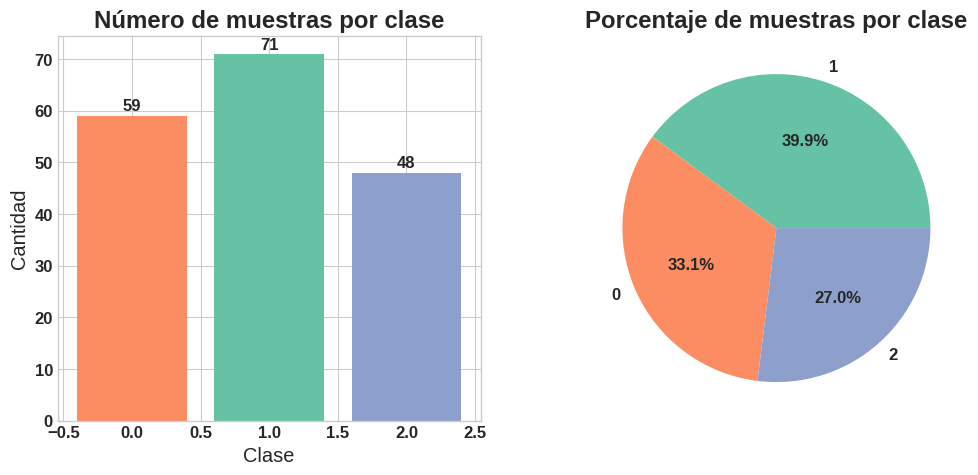

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
class_counts = df['target'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Número de muestras por clase', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(class_counts.values):
    #axes[0].text(i, v +1 , str(v), ha='center', fontweight='bold')
    axes[0].text(class_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(class_counts)))
axes[1].set_title('Porcentaje de muestras por clase', fontweight='bold')

plt.show()